In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import math

import keras
from keras import models
from keras import layers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense, Conv2D , SeparableConv2D, MaxPooling2D , Flatten , Dropout , BatchNormalization, Activation
from keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras.callbacks import ReduceLROnPlateau
from keras import backend as K
from keras import optimizers
from sklearn.metrics import classification_report, recall_score, precision_score, confusion_matrix, f1_score, accuracy_score
import tensorflow as tf

In [ ]:
train_data_dir = '/content/gdrive/MyDrive/COVIDGR/train/'
test_data_dir = '/content/gdrive/MyDrive/COVIDGR/Test/'

In [ ]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        # zoom_range=0.4,
        validation_split=0.2
        )

train_gen = train_datagen.flow_from_directory(
        directory = train_data_dir,
        target_size=(256, 256),
        batch_size=32,
        class_mode='categorical',
        subset='training'
        )
val_gen = train_datagen.flow_from_directory(
        directory = train_data_dir,
        target_size=(256, 256),
        batch_size=32,
        class_mode='categorical',
        subset='validation'
        )

Found 548 images belonging to 2 classes.
Found 136 images belonging to 2 classes.


In [ ]:
test_datagen = ImageDataGenerator(
        rescale=1./255
        )
y_act = test_datagen.flow_from_directory(
    directory = test_data_dir,
    target_size=(256,256),
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = True
)

Found 168 images belonging to 2 classes.


In [ ]:
image_size = (256,256,3)

In [ ]:
resnet_XrayPn_model = Sequential()

pretrained_model = tf.keras.applications.ResNet50(
                    include_top=False,
                    weights="imagenet",
                    input_shape=image_size,
                    pooling='avg',
                    classes=3,

)
for layer in pretrained_model.layers:
        layer.trainable = False

resnet_XrayPn_model.add(pretrained_model)
resnet_XrayPn_model.add(Flatten())
resnet_XrayPn_model.add(Dense(512, activation ='relu'))
resnet_XrayPn_model.add(Dense(3,activation='softmax'))


In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 246016)            0         
                                                                 
 dense (Dense)               (None, 128)               3

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics = ['acc'])

In [ ]:
from keras.callbacks import EarlyStopping
Early_stop = EarlyStopping(monitor = 'val_acc',patience = 10)

In [ ]:
history = model.fit(train_gen, validation_data=val_gen, epochs=30, callbacks=[Early_stop])

Epoch 1/30
38/38 [==============================] - 512s 13s/step - loss: 0.6982 - acc: 0.5671 - val_loss: 0.6129 - val_acc: 0.7600
Epoch 2/30
38/38 [==============================] - 315s 8s/step - loss: 0.5589 - acc: 0.7641 - val_loss: 0.5677 - val_acc: 0.7833
Epoch 3/30
38/38 [==============================] - 316s 8s/step - loss: 0.5065 - acc: 0.7889 - val_loss: 0.5800 - val_acc: 0.6733
Epoch 4/30
38/38 [==============================] - 314s 8s/step - loss: 0.4909 - acc: 0.7889 - val_loss: 0.4804 - val_acc: 0.7933
Epoch 5/30
38/38 [==============================] - 314s 8s/step - loss: 0.4512 - acc: 0.8104 - val_loss: 0.4621 - val_acc: 0.7800
Epoch 6/30
38/38 [==============================] - 314s 8s/step - loss: 0.4315 - acc: 0.8113 - val_loss: 0.4362 - val_acc: 0.8200
Epoch 7/30
38/38 [==============================] - 315s 8s/step - loss: 0.4751 - acc: 0.7897 - val_loss: 0.4769 - val_acc: 0.7667
Epoch 8/30
38/38 [==============================] - 312s 8s/step - loss: 0.4331 - 

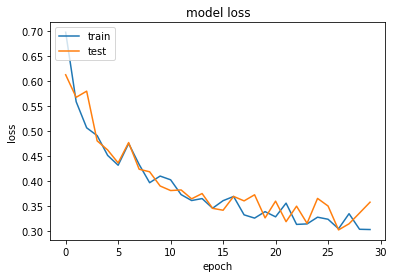

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

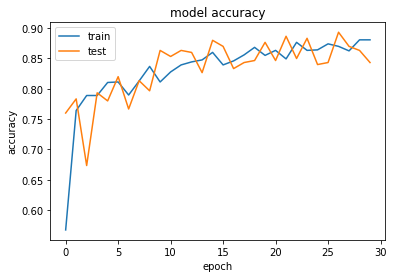

In [ ]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


              precision    recall  f1-score   support

           C       0.92      0.81      0.86        85
           N       0.83      0.93      0.88        85

    accuracy                           0.87       170
   macro avg       0.88      0.87      0.87       170
weighted avg       0.88      0.87      0.87       170



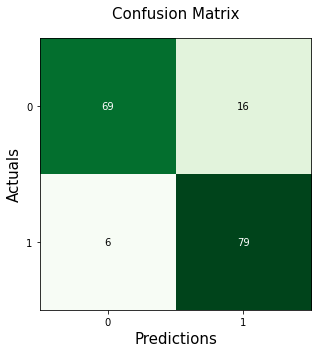

In [ ]:
print(metrics.classification_report(y_act, y_pred, labels=["C", "N"]))

from mlxtend.plotting import plot_confusion_matrix

fig, ax = plot_confusion_matrix(metrics.confusion_matrix( y_act, y_pred, labels=["C", "N"]), figsize=(5, 5), cmap=plt.cm.Greens)
plt.xlabel('Predictions', fontsize=15)
plt.ylabel('Actuals', fontsize=15)
plt.title('Confusion Matrix', fontsize=15)
plt.show()

In [ ]:
model.save('/content/gdrive/MyDrive/Covid_dataset/Seg_bin_class.h5')

In [ ]:
from keras.models import load_model

In [ ]:
Mod = load_model('/content/gdrive/MyDrive/Covid_dataset/Seg_bin_class.h5')

In [ ]:
image_path ='/content/gdrive/MyDrive/COVIDGR/Test/P/00f9707e0de334db70a7924a9de98368.jpg'

In [ ]:
from keras.preprocessing import image
test_image = image.load_img(image_path, target_size = (256,256,3))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result = Mod.predict(test_image)
answer = np.argmax(result,axis=1)
train_gen.class_indices
if result[0][0]==1:
    prediction = 'covid'
else :
    prediction = 'normal'
print(prediction)

covid


In [ ]:
import numpy as np
from sklearn.metrics import plot_confusion_matrix
from sklearn import metrics
import matplotlib.pyplot as plt
# Predicted values
y_pred = ["C", "N",  "C", "N",  "N", "C",  "N", "N",  "N", "N",  "N", "N",  "C", "N",  "C", "C",  "N", "C",   "C", "C",  "N", "N",  "N", "N",   "N", "N",  "N", "N",  "N", "N",  "N", "C",   "C", "C",  "N", "N", "N", "N",  "N", "N",  "N", "N","N", "N","C", "N","C", "N","C", "N",
         "C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N",
         "C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N",
         "C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N"]
# Printing the confusion matrix
# Actual values
y_act = ["C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N",
         "C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N",
         "C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N",
         "C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N","C", "N"]